<div align="center">

# 🛡️ The Rising Tide of Cyber Threats
### A Decade of Security Vulnerabilities, Analyzed (2015–2025)

![Status](https://img.shields.io/badge/status-complete-brightgreen)
![Dataset](https://img.shields.io/badge/dataset-210K%2B%20CVEs-red)
![Python](https://img.shields.io/badge/python-3.10+-blue)
![Libraries](https://img.shields.io/badge/libraries-Pandas%20%7C%20NumPy%20%7C%20Matplotlib-orange)

</div>

---

## 🎯 The Question

> In under a decade, has the world become more vulnerable to cyberattacks — and if so,
> which weaknesses keep resurfacing? This analysis examines **210,000+ publicly disclosed
> vulnerabilities (CVEs)** from 2015 to 2025 to uncover the trends shaping modern
> cybersecurity risk.

---

## 📖 What This Notebook Covers

| Step | What It Does |
|---|---|
| 🧹 **Clean** | Filter and prepare 10 years of CVE records for analysis |
| 🔢 **Compute** | Quantify the growth rate of vulnerabilities using NumPy |
| 📈 **Visualize** | Reveal trends across time, category, and severity |

---

## 📂 Data Source

Dataset: [`stasvinokur/cve-and-cwe-dataset-1999-2025`](https://huggingface.co/datasets/stasvinokur/cve-and-cwe-dataset-1999-2025)
on Hugging Face — built from the official **National Vulnerability Database (NVD)**,
filtered here to the 2015–2025 window (210,206 records).

---

In [1]:
import pandas as pd

df = pd.read_csv("CVE_CWE_2025.csv")
print(df.shape)
df.head()

(280694, 8)


,ID,CVE-ID,CVSS-V4,CVSS-V3,CVSS-V2,SEVERITY,DESCRIPTION,CWE-ID
0,1,CVE-1999-0001,NaN,NaN,5.0,MEDIUM,ip_input.c in BSD-derived TCP/IP implementatio...,CWE-20
1,2,CVE-1999-0002,NaN,NaN,10.0,HIGH,Buffer overflow in NFS mountd gives root acces...,CWE-119
2,3,CVE-1999-0003,NaN,NaN,10.0,HIGH,Execute commands as root via buffer overflow i...,NVD-CWE-Other
3,4,CVE-1999-0004,NaN,NaN,5.0,MEDIUM,"MIME buffer overflow in email clients, e.g. So...",NVD-CWE-Other
4,5,CVE-1999-0005,NaN,NaN,10.0,HIGH,Arbitrary command execution via IMAP buffer ov...,NVD-CWE-Other


In [16]:
df["Year"] = df["CVE-ID"].str.extract(r"CVE-(\d{4})-").astype(int)
print(df["Year"].min(), df["Year"].max())
print(df["Year"].value_counts().sort_index().tail(15))


1999 2025
Year
2011     4609
2012     5442
2013     6175
2014     8408
2015     8082
2016     9277
2017    14679
2018    15862
2019    15555
2020    18971
2021    22249
2022    25372
2023    29164
2024    37556
2025    13439
Name: count, dtype: int64


In [3]:
df_recent = df[df["Year"] >= 2015].copy()
print(df_recent.shape)
df_recent.head()

(210206, 9)


,ID,CVE-ID,CVSS-V4,CVSS-V3,CVSS-V2,SEVERITY,DESCRIPTION,CWE-ID,Year
70488,70489,CVE-2015-0001,NaN,NaN,1.9,LOW,The Windows Error Reporting (WER) component in...,CWE-264,2015
70489,70490,CVE-2015-0002,NaN,NaN,7.2,HIGH,The AhcVerifyAdminContext function in ahcache....,CWE-264,2015
70490,70491,CVE-2015-0003,NaN,NaN,6.9,MEDIUM,win32k.sys in the kernel-mode drivers in Micro...,CWE-476,2015
70491,70492,CVE-2015-0004,NaN,NaN,7.2,HIGH,The User Profile Service (aka ProfSvc) in Micr...,CWE-264,2015
70492,70493,CVE-2015-0005,NaN,NaN,4.3,MEDIUM,The NETLOGON service in Microsoft Windows Serv...,CWE-254,2015


In [4]:
df_recent.to_csv("cve_last_10_years.csv", index=False)

In [5]:
import os
size_mb = os.path.getsize("cve_last_10_years.csv") / (1024 * 1024)
print(f"File size: {size_mb:.2f} MB")

File size: 77.58 MB


In [18]:
df_slim = df_recent[["CVE-ID", "CVSS-V3", "CVSS-V2", "SEVERITY", "CWE-ID", "Year"]].copy()
df_slim.to_csv("cve_last_10_years_slim.csv", index=False)

size_mb = os.path.getsize("cve_last_10_years_slim.csv") / (1024 * 1024)
print(f"New file size: {size_mb:.2f} MB")

New file size: 8.42 MB


In [8]:
df_slim = pd.read_csv("cve_last_10_years_slim.csv")
print(df_slim.shape)
print(df_slim.isnull().sum())

(210206, 6)
CVE-ID          0
CVSS-V3      9104
CVSS-V2     93641
SEVERITY     2104
CWE-ID          0
Year            0
dtype: int64


In [19]:
df_clean = df_slim.dropna(subset=["SEVERITY"]).copy()
print(df_clean.shape)

(208102, 6)


In [10]:
counts_by_year = df_clean["Year"].value_counts().sort_index()

growth_rate = ((counts_by_year[2024] - counts_by_year[2015]) / counts_by_year[2015]) * 100
print(f"CVEs in 2015: {counts_by_year[2015]}")
print(f"CVEs in 2024: {counts_by_year[2024]}")
print(f"Growth rate (2015→2024): {growth_rate:.1f}%")

CVEs in 2015: 8082
CVEs in 2024: 36815
Growth rate (2015→2024): 355.5%


## 📈 Vulnerability Growth Over Time
Tracking the number of published CVEs per year from 2015 to 2025 reveals how
rapidly the security landscape has expanded.

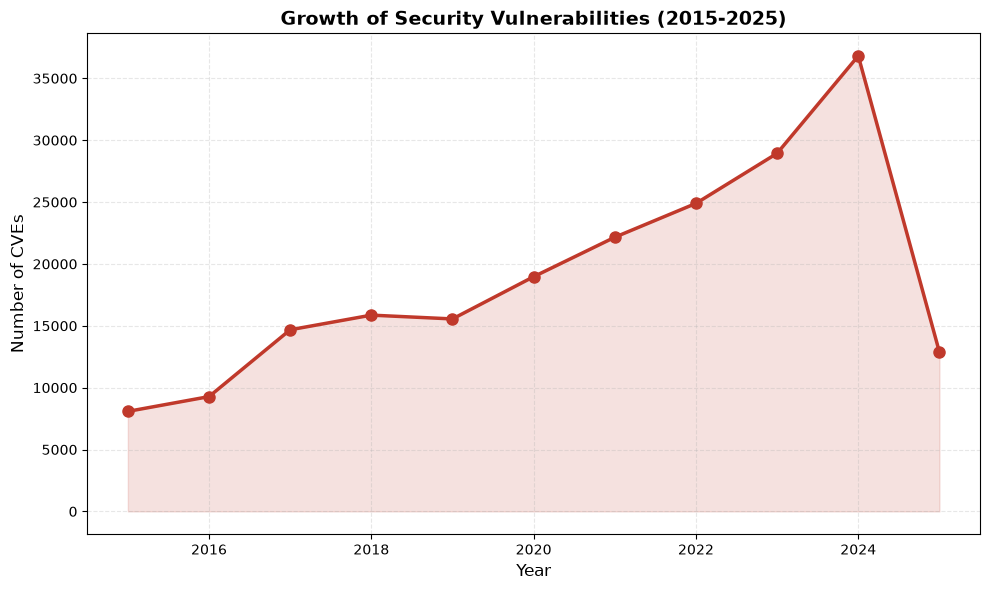

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(10, 6))
plt.plot(counts_by_year.index, counts_by_year.values, 
         marker='o', markersize=8, color='#C0392B', linewidth=2.5)
plt.fill_between(counts_by_year.index, counts_by_year.values, alpha=0.15, color='#C0392B')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of CVEs", fontsize=12)
plt.title("Growth of Security Vulnerabilities (2015-2025)", fontsize=14, fontweight='bold')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

## 🐛 Most Common Vulnerability Types
Identifying the top 10 CWE categories reveals which coding weaknesses are
most frequently exploited across the past decade.

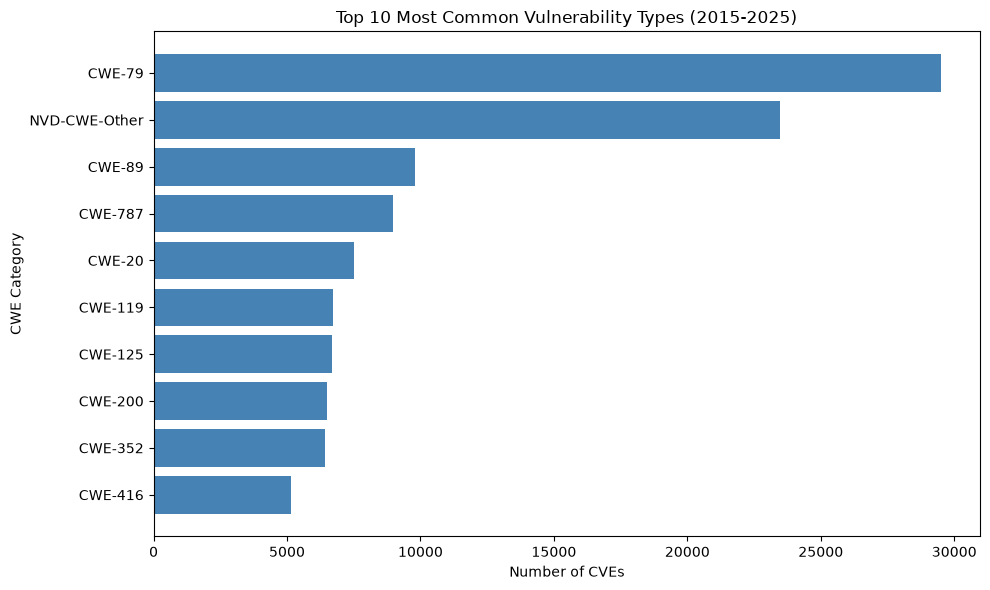

In [14]:
top_cwe = df_clean["CWE-ID"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_cwe.index[::-1], top_cwe.values[::-1], color='steelblue')
plt.xlabel("Number of CVEs")
plt.ylabel("CWE Category")
plt.title("Top 10 Most Common Vulnerability Types (2015-2025)")
plt.tight_layout()
plt.show()

## ⚠️ Severity Distribution
Examining how vulnerabilities are distributed across severity levels shows
whether most reported issues are critical or manageable.

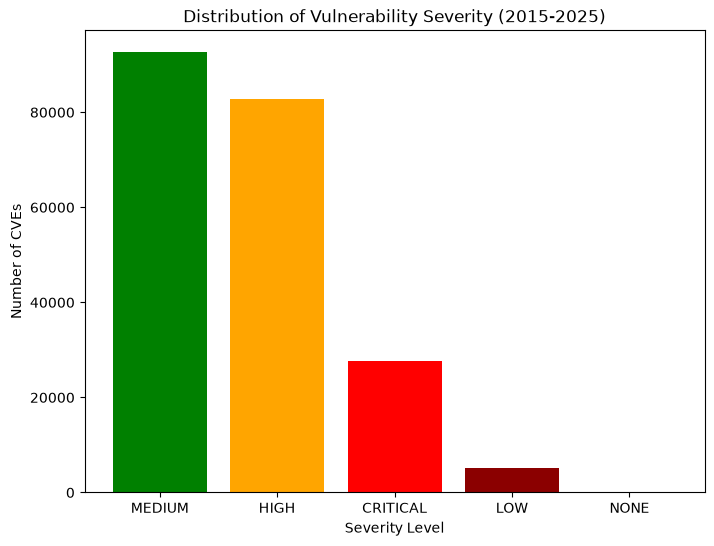

In [15]:
severity_counts = df_clean["SEVERITY"].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(severity_counts.index, severity_counts.values, color=['green', 'orange', 'red', 'darkred'])
plt.xlabel("Severity Level")
plt.ylabel("Number of CVEs")
plt.title("Distribution of Vulnerability Severity (2015-2025)")
plt.show()

## 📌 Key Findings

- **355.5% growth** in reported vulnerabilities between 2015 and 2024 (8,082 → 36,815)
- The most common vulnerability type was **CWE-79 (Cross-Site Scripting / XSS)**,
  followed closely by uncategorized "NVD-CWE-Other" entries and **CWE-89 (SQL Injection)**
- The majority of vulnerabilities were rated **MEDIUM** severity (~90,000), followed by
  **HIGH** (~80,000) and **CRITICAL** (~28,000) — meaning most reported issues, while
  numerous, are not the most severe category

## 💡 Why This Matters
The exponential rise in reported CVEs reflects the growing complexity of modern
software systems and the increasing attention paid to security research. The dominance
of **Cross-Site Scripting (XSS)** as the leading vulnerability type highlights a
persistent, well-known weakness in web application security that continues to affect
software despite being a long-documented risk. Prioritizing input validation and secure
coding practices around XSS and SQL Injection